<a href="https://colab.research.google.com/github/abutalebco/chain-of-density/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chain of Density Summarizer

I'm using a technique called Chain of Density Summarization to summarize the first part of Deep Learning Book by Ian Goodfellow and Yoshua Bengio and Aaron Courville. You can learn more about this technique in the [From Sparse to Dense: GPT-4 Summarization with Chain of Density Prompting paper.](https://arxiv.org/abs/2309.04269)

I'm using Gemini API for gemini-3.1-flash-lite model and Opik to track the LLM calls.

Future goals:
- Automated Evaluation System
- Multi-document summarization

In [1]:
!pip install google-genai opik

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.9/155.9 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 6.4 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of typer to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.7/70.7 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 80.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 463.6/463.6 kB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 71.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.1/278.1 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 6.7 MB/s eta

In [2]:
import opik

from google.colab import userdata

OPIK_API_KEY = userdata.get('OPIK_API_KEY')

opik.configure(
    workspace="abutalebco",
    api_key=OPIK_API_KEY,
    project_name="chain-of-density"
)

OPIK: Opik is already configured. You can check the settings by viewing the config file at /root/.opik.config
OPIK: Configuration completed successfully. Traces will be logged to 'chain-of-density' project. To change the destination project, see: https://www.comet.com/docs/opik/tracing/log_traces#configuring-the-project-name


In [3]:
import opik

ITERATION_SUMMARY_PROMPT = opik.Prompt(
    name="iteration summary prompt",
    prompt="""
Document: {{document}}
Current summary: {{current_summary}}
Instruction to focus on: {{instruction}}

Generate a concise, entity-dense, and highly technical summary from the provided Document that specifically addresses the given Instruction.

Guidelines:
- Make every word count: If there is a current summary re-write it to improve flow, density and conciseness.
- Remove uninformative phrases like "the article discusses".
- The summary should become highly dense and concise yet self-contained, e.g. , easily understood without the Document.
- Make sure that the summary specifically addresses the given Instruction
""".rstrip().lstrip(),
)

FINAL_SUMMARY_PROMPT = opik.Prompt(
    name="final summary prompt",
    prompt="""
Given this summary: {{current_summary}}
And this instruction to focus on: {{instruction}}
Create an extremely dense, final summary that captures all key technical information in the most concise form possible, while specifically addressing the given instruction.
""".rstrip().lstrip(),
)

In [16]:
from google import genai
from opik.integrations.genai import track_genai

from google.colab import userdata

GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')

client = genai.Client(api_key=GEMINI_API_KEY)
gemini_client = track_genai(client)

# ===================================================

@opik.track
def summarize_current_summary(
    document: str,
    instruction: str,
    current_summary: str,
    model: str = "gemini-3.1-flash-lite",
):
    prompt = ITERATION_SUMMARY_PROMPT.format(
        document=document, current_summary=current_summary, instruction=instruction
    )

    response = gemini_client.models.generate_content(
        model=model,
        contents=prompt,
    )

    return response.text


@opik.track
def iterative_density_summarization(
    document: str,
    instruction: str,
    density_iterations: int,
    model: str = "gemini-3.1-flash-lite",
):
    summary = ""
    for iteration in range(1, density_iterations + 1):
        summary = summarize_current_summary(document, instruction, summary, model)
    return summary


@opik.track
def final_summary(instruction: str, current_summary: str, model: str = "gemini-3.1-flash-lite"):
    prompt = FINAL_SUMMARY_PROMPT.format(
        current_summary=current_summary, instruction=instruction
    )

    return (
        gemini_client.models.generate_content(
            model=model,
            contents=prompt,
        )
    )


@opik.track()
def chain_of_density_summarization(
    document: str,
    instruction: str,
    model: str = "gemini-3.1-flash-lite",
    density_iterations: int = 2,
):
    summary = iterative_density_summarization(
        document, instruction, density_iterations, model
    )
    final_summary_text = final_summary(instruction, summary, model)

    return final_summary_text

In [18]:
import textwrap

document = """
The Deep Learning textbook by Goodfellow, Bengio, and Courville is one of the most comprehensive references in the field,
structured across three parts. The first part, Applied Math and Machine Learning Basics, lays the mathematical foundation necessary for everything that follows.
It opens with Linear Algebra, covering the vectors, matrices, and operations that neural networks are built upon, then moves to Probability and Information Theory,
which teaches how to reason under uncertainty using tools like Bayes' rule and entropy. Numerical Computation follows, addressing how to practically optimize functions —
finding minima through techniques like gradient descent while maintaining numerical stability. The part closes with Machine Learning Basics,
where the core ML framework is established: defining a model, designing a cost function, and minimizing it through a training algorithm.
This framework, simple as it sounds, underlies virtually every machine learning approach — deep or otherwise — and serves as the launchpad for all the advanced concepts covered in the rest of the book.
"""

instructions = "Summarize the main concepts and benefits to read this book, and highlight both its potential and associated challenges."

summary = chain_of_density_summarization(document, instructions)

print("\n".join(textwrap.wrap(summary.text, width=80)))

Goodfellow et al.’s *Deep Learning* serves as the definitive theoretical
blueprint for neural networks, synthesizing linear algebra, probability,
information theory, and optimization into a unified framework for gradient-based
training. **Benefits:** It provides a rigorous pedagogical bridge between
abstract mathematical foundations and practical implementation, essential for
mastering cost-function minimization. **Challenges:** Its steep barrier to entry
necessitates advanced proficiency in multivariate calculus and probabilistic
reasoning, rendering the text inaccessible to those lacking significant
quantitative prerequisites.


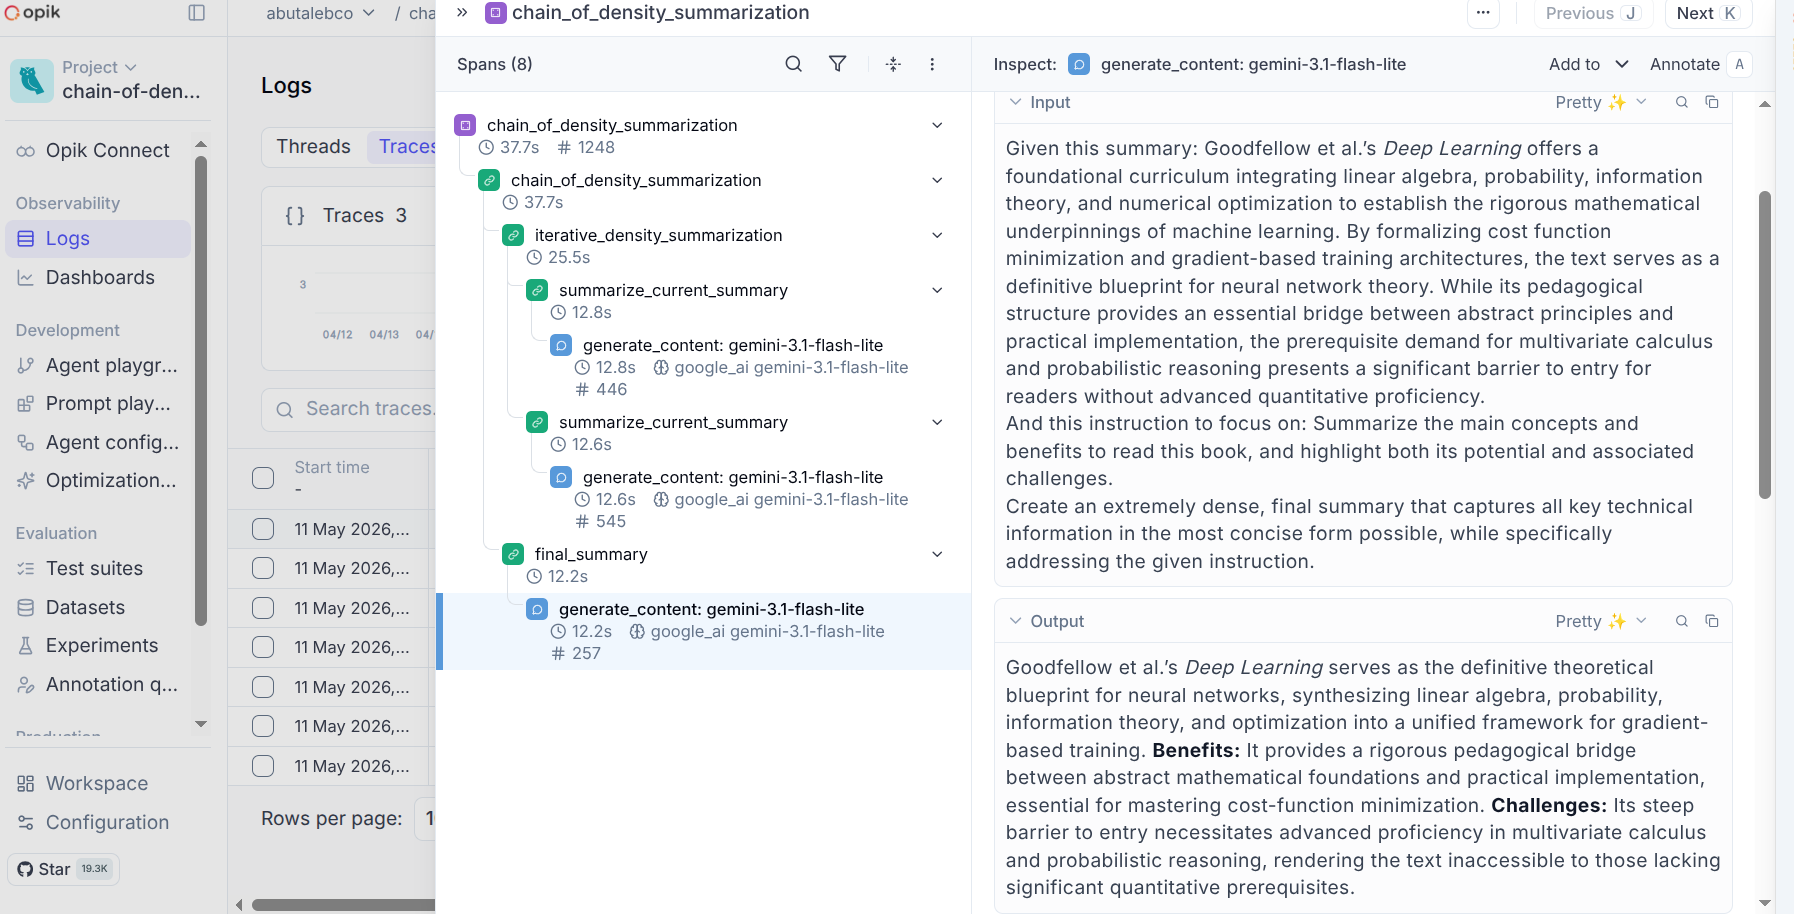

In [20]:
import opik

dataset_items = [
    {
        "pdf_url": "https://www.deeplearningbook.org/contents/linear_algebra.html",
        "title": "Linear Algebra",
        "instruction": "Summarize the concepts in this chapter and name the basic steps to build a strong algebra understanding.",
    },
    {
        "pdf_url": "https://www.deeplearningbook.org/contents/prob.html",
        "title": "Probability and Information Theory",
        "instruction": "How the probability and information theory play an important role in AI/ML field?",
    },
    {
        "pdf_url": "https://www.deeplearningbook.org/contents/numerical.html",
        "title": "Numerical Computation",
        "instruction": "What is numerical computation? How it is importance in AI/ML field?",
    },
    {
        "pdf_url": "https://www.deeplearningbook.org/contents/ml.html",
        "title": "Machine Learning Basics",
        "instruction": "Summarize the concepts, approches and assumptions in ML solutions.",
    },
]

client = opik.Opik()
DATASET_NAME = "Deep Learning Book"
dataset = client.get_or_create_dataset(name=DATASET_NAME)
dataset.insert(dataset_items)

# @book{Goodfellow-et-al-2016,
#     title={Deep Learning},
#     author={Ian Goodfellow and Yoshua Bengio and Aaron Courville},
#     publisher={MIT Press},
#     note={\url{http://www.deeplearningbook.org}},
#     year={2016}
# }